In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from DataTransformation import LowPassFilter, PrincipalComponentAnalysis

In [ ]:
from TemporalAbstraction import NumericalAbstraction

In [ ]:
df = pd.read_pickle("../../data/interim/02_outliers_removed_chauvenets.pkl")

In [ ]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9009 entries, 2019-01-11 15:08:05.200000 to 2019-01-20 17:33:27.800000
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   acc_x        9005 non-null   float64
 1   acc_y        8998 non-null   float64
 2   acc_z        8999 non-null   float64
 3   gyr_x        8984 non-null   float64
 4   gyr_y        8938 non-null   float64
 5   gyr_z        8945 non-null   float64
 6   label        9009 non-null   str    
 7   category     9009 non-null   str    
 8   participant  9009 non-null   str    
 9   set          9009 non-null   int64  
dtypes: float64(6), int64(1), str(3)
memory usage: 774.2 KB


In [ ]:
predictor_columns = list(df.columns[:6])

In [ ]:
# plot settings
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

In [ ]:
for col in predictor_columns:
    df[col] = df[col].interpolate()

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9009 entries, 2019-01-11 15:08:05.200000 to 2019-01-20 17:33:27.800000
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   acc_x        9009 non-null   float64
 1   acc_y        9009 non-null   float64
 2   acc_z        9009 non-null   float64
 3   gyr_x        9009 non-null   float64
 4   gyr_y        9009 non-null   float64
 5   gyr_z        9009 non-null   float64
 6   label        9009 non-null   str    
 7   category     9009 non-null   str    
 8   participant  9009 non-null   str    
 9   set          9009 non-null   int64  
dtypes: float64(6), int64(1), str(3)
memory usage: 774.2 KB


<Axes: xlabel='epoch (ms)'>

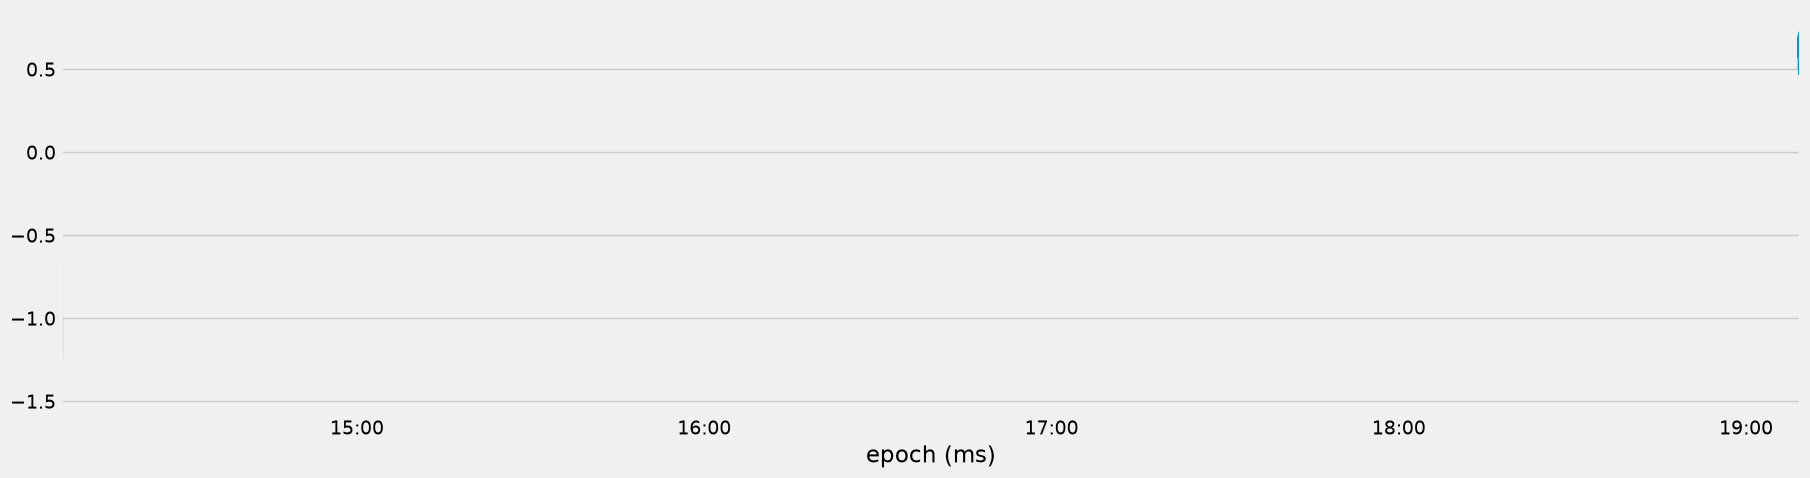

In [ ]:
df[df["set"] == 25]["acc_y"].plot()
df[df["set"] == 50]["acc_y"].plot()

<Axes: xlabel='epoch (ms)'>

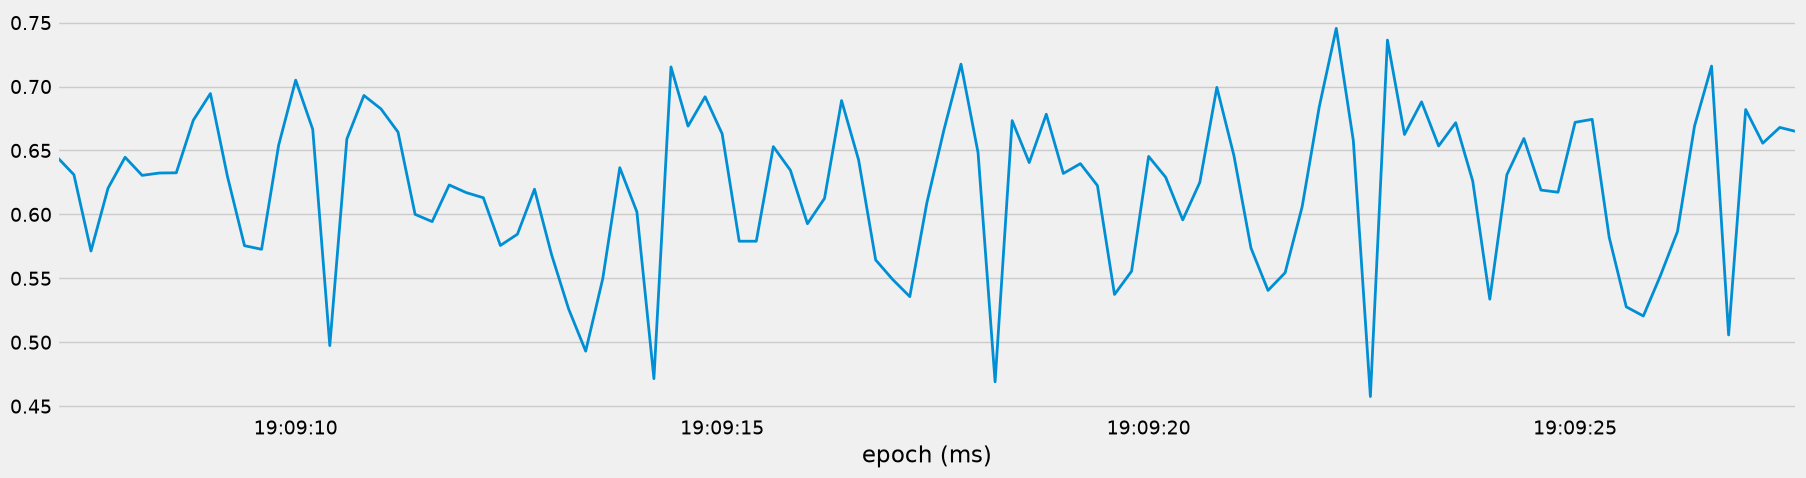

In [ ]:
df[df["set"] == 25]["acc_y"].plot()

<Axes: xlabel='epoch (ms)'>

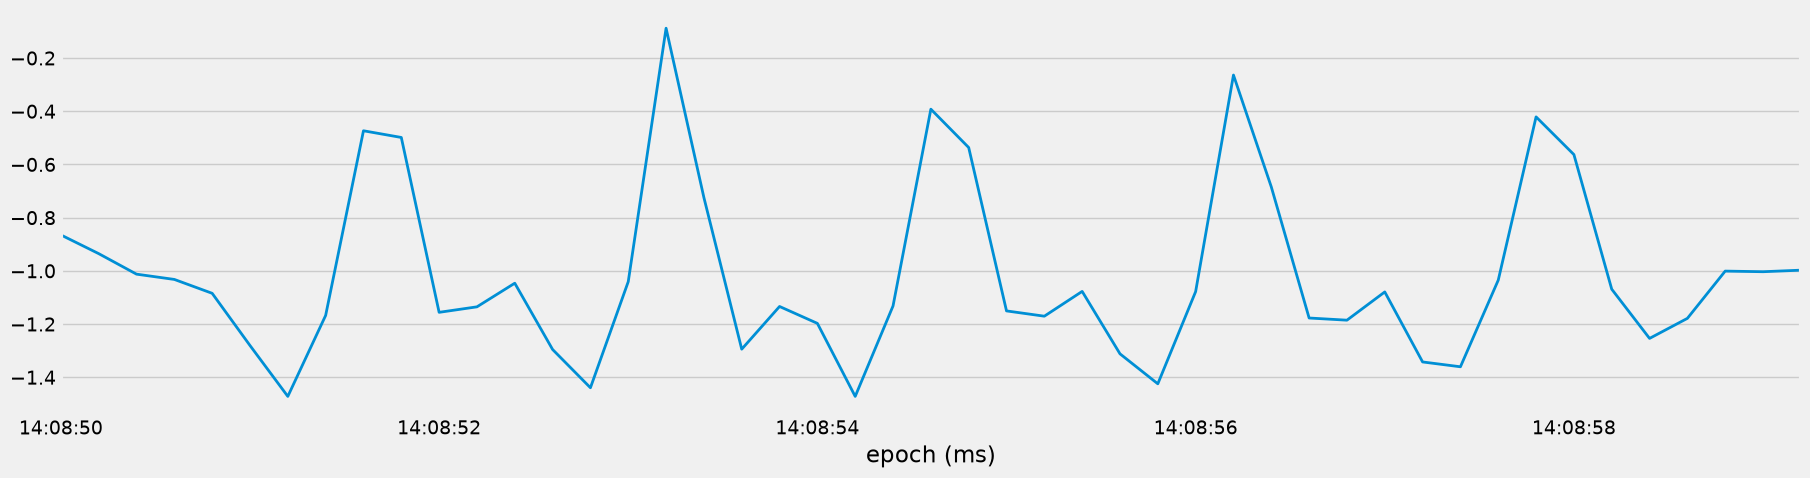

In [ ]:
df[df["set"] == 50]["acc_y"].plot()

In [ ]:
duration = df[df["set"] == 1].index[-1] - df[df["set"] == 1].index[0]

In [ ]:
duration.seconds

16

In [ ]:
for s in df["set"].unique():

    start = df[df["set"] == s].index[0]
    stop = df[df["set"] == s].index[-1]

    duration = stop - start
    df.loc[(df["set"] == s), "duration"] = duration.seconds

In [ ]:
duration_df = df.groupby(["category"])["duration"].mean()

In [ ]:
duration_df.iloc[0] / 5
duration_df.iloc[1] / 10

np.float64(2.4942528735632186)

In [ ]:
df_lowpass = df.copy()
LowPass = LowPassFilter()

In [ ]:
fs = 1000 / 200

In [ ]:
cutoff = 1.2

In [ ]:
df_lowpass = LowPass.low_pass_filter(df_lowpass, "acc_y", fs, cutoff, order=5)

In [ ]:
subset = df_lowpass[df_lowpass["set"] == 45]

In [ ]:
print(subset["label"][0])

KeyError: 0

In [ ]:
subset = df_lowpass[df_lowpass["set"] == 45]

In [ ]:
print(subset["label"][0])

KeyError: 0

In [ ]:
subset

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,label,category,participant,set,duration,acc_y_lowpass
epoch (ms),,,,,,,,,,,,
2019-01-14 13:54:34.800,-0.058500,1.412000,0.003167,-0.24400,10.3902,-22.8172,ohp,heavy,C,45,15.0,1.277609
2019-01-14 13:54:35.000,-0.202000,1.180333,0.101333,39.34160,24.2865,-85.0976,ohp,heavy,C,45,15.0,1.148728
2019-01-14 13:54:35.200,-0.297500,0.640500,0.199500,-16.15860,38.1828,22.1830,ohp,heavy,C,45,15.0,0.802074
2019-01-14 13:54:35.400,-0.232333,0.759667,0.157667,-1.68300,5.7682,75.4634,ohp,heavy,C,45,15.0,0.587073
2019-01-14 13:54:35.600,-0.081500,0.513500,0.028500,16.40240,-5.8048,27.0122,ohp,heavy,C,45,15.0,0.676618
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-14 13:54:49.600,-0.322000,0.800500,0.046500,11.04900,-19.2316,-33.7560,ohp,heavy,C,45,15.0,0.783794
2019-01-14 13:54:49.800,-0.394667,0.811333,0.061667,12.65860,-23.6706,-12.1338,ohp,heavy,C,45,15.0,0.796208
2019-01-14 13:54:50.000,-0.400000,0.920500,0.117000,27.34140,-40.7318,53.9024,ohp,heavy,C,45,15.0,0.907356


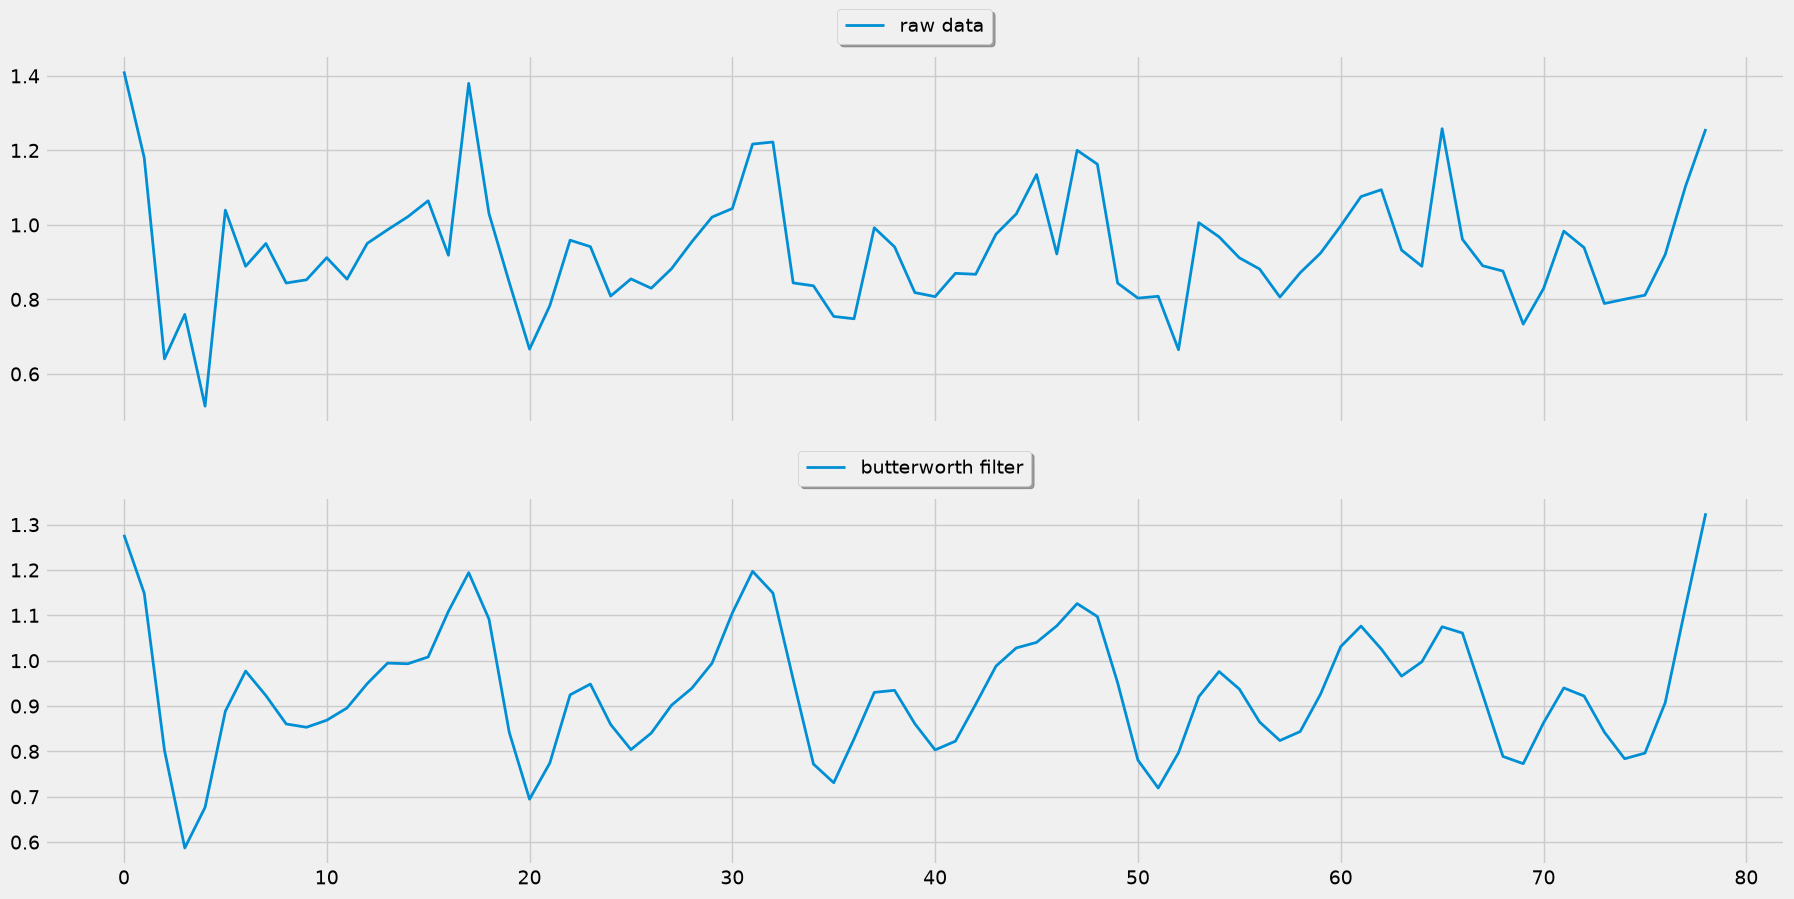

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(20, 10))
ax[0].plot(subset["acc_y"].reset_index(drop=True), label="raw data")
ax[1].plot(subset["acc_y_lowpass"].reset_index(drop=True), label="butterworth filter")
ax[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), fancybox=True, shadow=True)
ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), fancybox=True, shadow=True)

In [ ]:
for col in predictor_columns:
    df_lowpass = LowPass.low_pass_filter(df_lowpass, col, fs, cutoff, order=5)
    df_lowpass[col] = df_lowpass[col + "_lowpass"]
    del df_lowpass[col + "_lowpass"]

In [ ]:
df_pca = df_lowpass.copy()
PCA = PrincipalComponentAnalysis()

In [ ]:
pc_values = PCA.determine_pc_explained_variance(df_pca, predictor_columns)

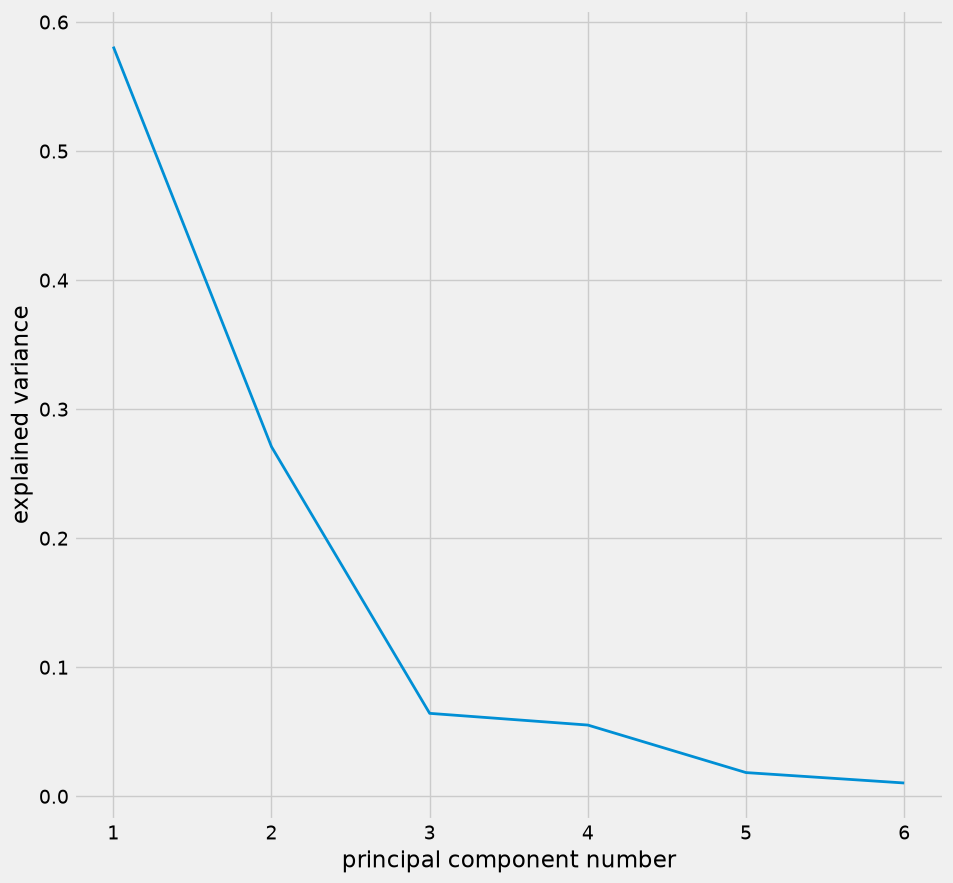

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(range(1, len(predictor_columns) + 1), pc_values)
plt.xlabel("principal component number")
plt.ylabel("explained variance")
plt.show()

In [ ]:
df_pca = PCA.apply_pca(df_pca, predictor_columns, 3)

In [ ]:
subset = df_pca[df_pca["set"] == 35]

<Axes: xlabel='epoch (ms)'>

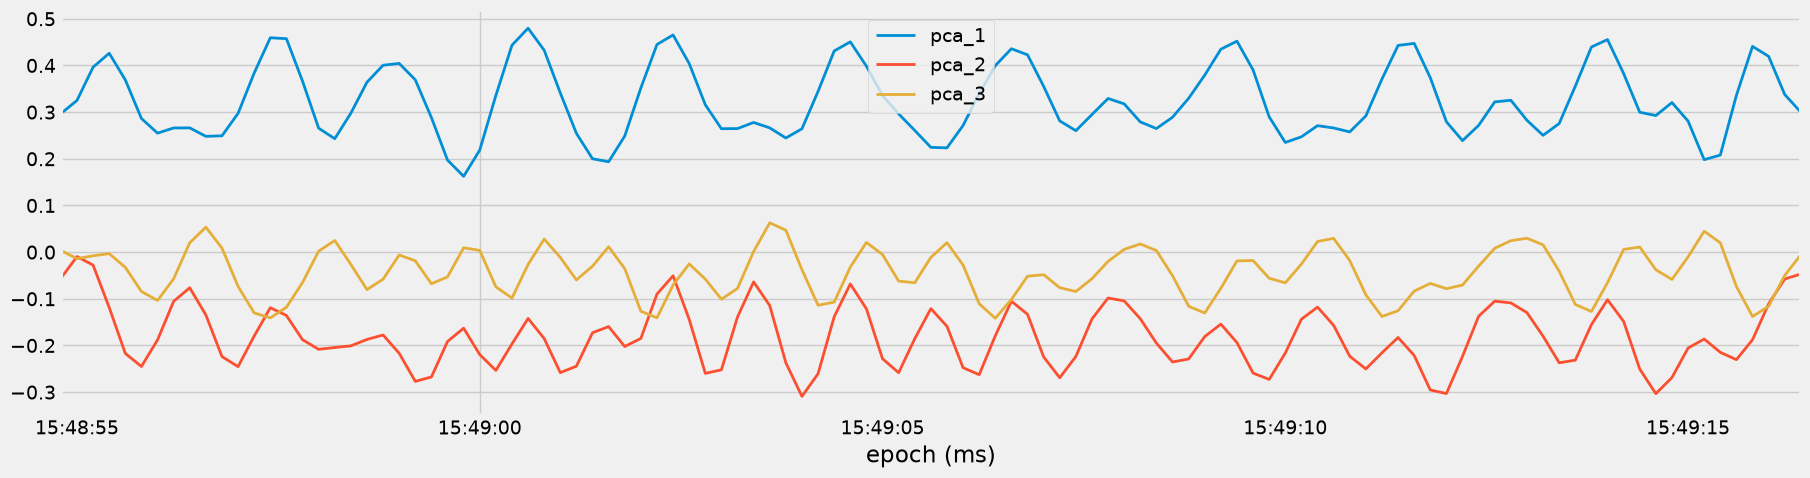

In [ ]:
subset[["pca_1", "pca_2", "pca_3"]].plot()

In [ ]:
df_squared = df_pca.copy()

In [ ]:
acc_r = df_squared["acc_x"] ** 2 + df_squared["acc_y"] ** 2 + df_squared["acc_z"] ** 2
gyr_r = df_squared["gyr_x"] ** 2 + df_squared["gyr_y"] ** 2 + df_squared["gyr_z"] ** 2

In [ ]:
df_squared["acc_r"] = np.sqrt(acc_r)
df_squared["gyr_r"] = np.sqrt(gyr_r)

In [ ]:
subset = df_squared[df_squared["set"] == 14]

array([<Axes: xlabel='epoch (ms)'>, <Axes: xlabel='epoch (ms)'>],
      dtype=object)

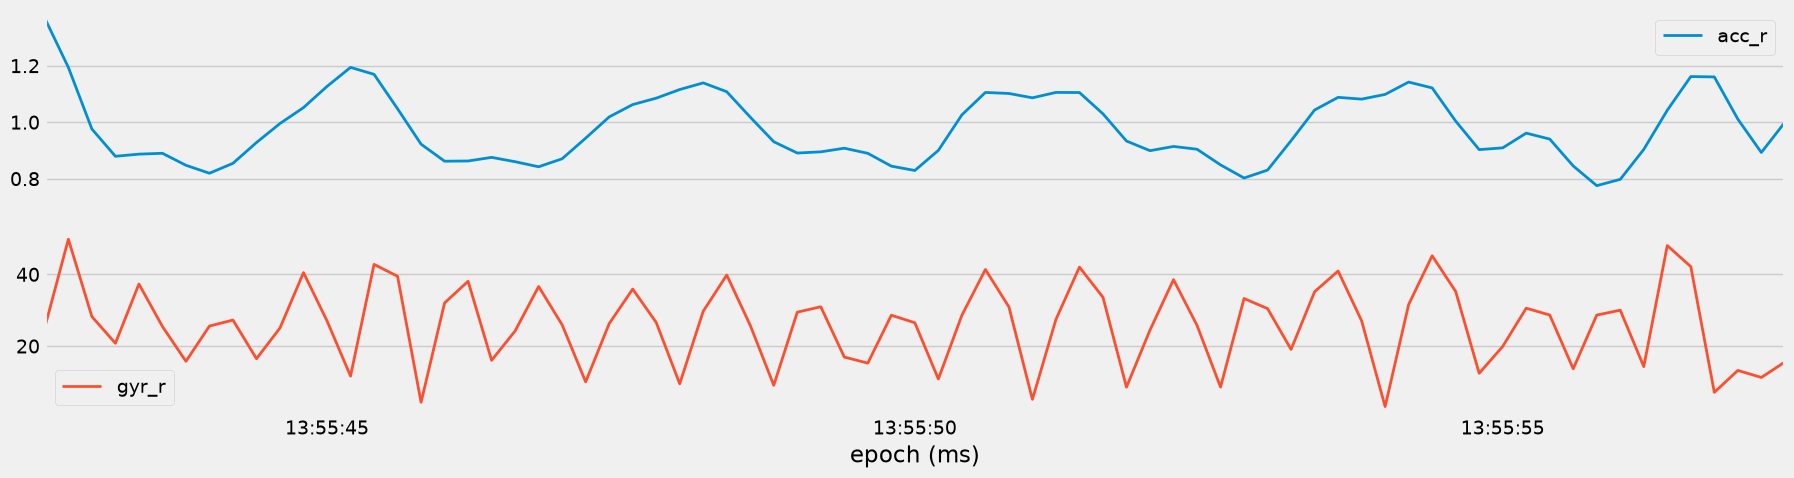

In [ ]:
subset[["acc_r", "gyr_r"]].plot(subplots=True)

In [ ]:
df_temporal = df_squared.copy()
NumAbs = NumericalAbstraction()

In [ ]:
predictor_columns = predictor_columns + ["acc_r", "gyr_r"]

In [ ]:
predictor_columns

['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z', 'acc_r', 'gyr_r']

In [ ]:
ws = int(1000/200)

In [ ]:
for col in predictor_columns:
    df_temporal = NumAbs.abstract_numerical(df_temporal, [col], ws, "mean")
    df_temporal = NumAbs.abstract_numerical(df_temporal, [col], ws, "std")

In [ ]:
df_temporal

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,label,category,participant,set,...,gyr_x_temp_mean_ws_5,gyr_x_temp_std_ws_5,gyr_y_temp_mean_ws_5,gyr_y_temp_std_ws_5,gyr_z_temp_mean_ws_5,gyr_z_temp_std_ws_5,acc_r_temp_mean_ws_5,acc_r_temp_std_ws_5,gyr_r_temp_mean_ws_5,gyr_r_temp_std_ws_5
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013494,0.977001,-0.070995,-1.896395,2.439080,0.939616,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.400,0.006869,0.970257,-0.067545,2.129685,0.528678,-1.248135,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.600,-0.009603,0.963589,-0.073447,4.151973,-2.092258,-0.929804,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.800,-0.022998,0.965441,-0.083731,2.074477,-3.626288,0.880509,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:06.000,-0.020032,0.966784,-0.093783,1.041930,-1.219897,-2.260590,bench,heavy,B,30,...,1.500334,1.975086,-0.794137,2.101951,-0.523681,1.250569,0.971920,0.004416,3.507335,0.858825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.045056,-0.974791,-0.061752,3.273522,-4.487268,0.133850,row,medium,E,90,...,-11.816937,17.831662,0.603702,5.346850,7.165439,6.227556,1.079434,0.120865,19.162630,14.473459
2019-01-20 17:33:27.200,-0.042806,-1.020916,-0.057715,-2.514546,-2.449224,1.255524,row,medium,E,90,...,-4.923778,12.693305,-1.469373,3.932028,4.409868,5.078760,1.098084,0.102142,11.768908,10.474589
2019-01-20 17:33:27.400,-0.047074,-1.051656,-0.066326,-0.673530,-1.799975,1.193779,row,medium,E,90,...,0.697498,4.394449,-2.997093,1.570800,1.931172,2.207628,1.065057,0.082144,5.749964,2.605498


In [ ]:
df_temporal_list = []
for s in df_temporal["set"].unique():
    subset = df_temporal[df_temporal["set"] == s].copy()
    for col in predictor_columns:
        subset = NumAbs.abstract_numerical(subset, [col], ws, "mean")
        subset = NumAbs.abstract_numerical(subset, [col], ws, "std")
    df_temporal_list.append(subset)

pd.concat(df_temporal_list)

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,label,category,participant,set,...,gyr_x_temp_mean_ws_5,gyr_x_temp_std_ws_5,gyr_y_temp_mean_ws_5,gyr_y_temp_std_ws_5,gyr_z_temp_mean_ws_5,gyr_z_temp_std_ws_5,acc_r_temp_mean_ws_5,acc_r_temp_std_ws_5,gyr_r_temp_mean_ws_5,gyr_r_temp_std_ws_5
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013494,0.977001,-0.070995,-1.896395,2.439080,0.939616,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.400,0.006869,0.970257,-0.067545,2.129685,0.528678,-1.248135,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.600,-0.009603,0.963589,-0.073447,4.151973,-2.092258,-0.929804,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.800,-0.022998,0.965441,-0.083731,2.074477,-3.626288,0.880509,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:06.000,-0.020032,0.966784,-0.093783,1.041930,-1.219897,-2.260590,bench,heavy,B,30,...,1.500334,1.975086,-0.794137,2.101951,-0.523681,1.250569,0.971920,0.004416,3.507335,0.858825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.045056,-0.974791,-0.061752,3.273522,-4.487268,0.133850,row,medium,E,90,...,-11.816937,17.831662,0.603702,5.346850,7.165439,6.227556,1.079434,0.120865,19.162630,14.473459
2019-01-20 17:33:27.200,-0.042806,-1.020916,-0.057715,-2.514546,-2.449224,1.255524,row,medium,E,90,...,-4.923778,12.693305,-1.469373,3.932028,4.409868,5.078760,1.098084,0.102142,11.768908,10.474589
2019-01-20 17:33:27.400,-0.047074,-1.051656,-0.066326,-0.673530,-1.799975,1.193779,row,medium,E,90,...,0.697498,4.394449,-2.997093,1.570800,1.931172,2.207628,1.065057,0.082144,5.749964,2.605498


In [ ]:
df_temporal.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9009 entries, 2019-01-11 15:08:05.200000 to 2019-01-20 17:33:27.800000
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   acc_x                 9009 non-null   float64
 1   acc_y                 9009 non-null   float64
 2   acc_z                 9009 non-null   float64
 3   gyr_x                 9009 non-null   float64
 4   gyr_y                 9009 non-null   float64
 5   gyr_z                 9009 non-null   float64
 6   label                 9009 non-null   str    
 7   category              9009 non-null   str    
 8   participant           9009 non-null   str    
 9   set                   9009 non-null   int64  
 10  duration              9009 non-null   float64
 11  pca_1                 9009 non-null   float64
 12  pca_2                 9009 non-null   float64
 13  pca_3                 9009 non-null   float64
 14  acc_r                 9009 non-nu

In [ ]:
subset[["acc_y", "acc_mean_temp_mean_ws_5", "acc_y_temp_std_ws_5"]].plot()

KeyError: "['acc_mean_temp_mean_ws_5'] not in index"

<Axes: xlabel='epoch (ms)'>

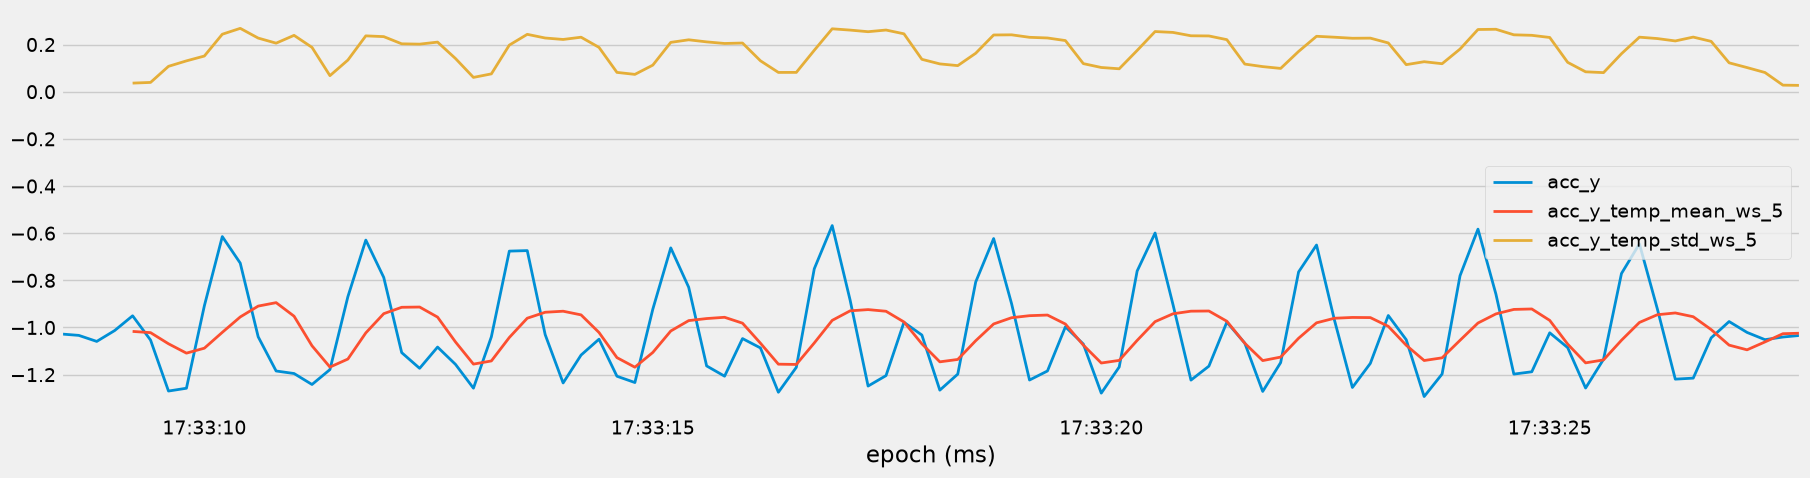

In [ ]:
subset[["acc_y", "acc_y_temp_mean_ws_5", "acc_y_temp_std_ws_5"]].plot()

<Axes: xlabel='epoch (ms)'>

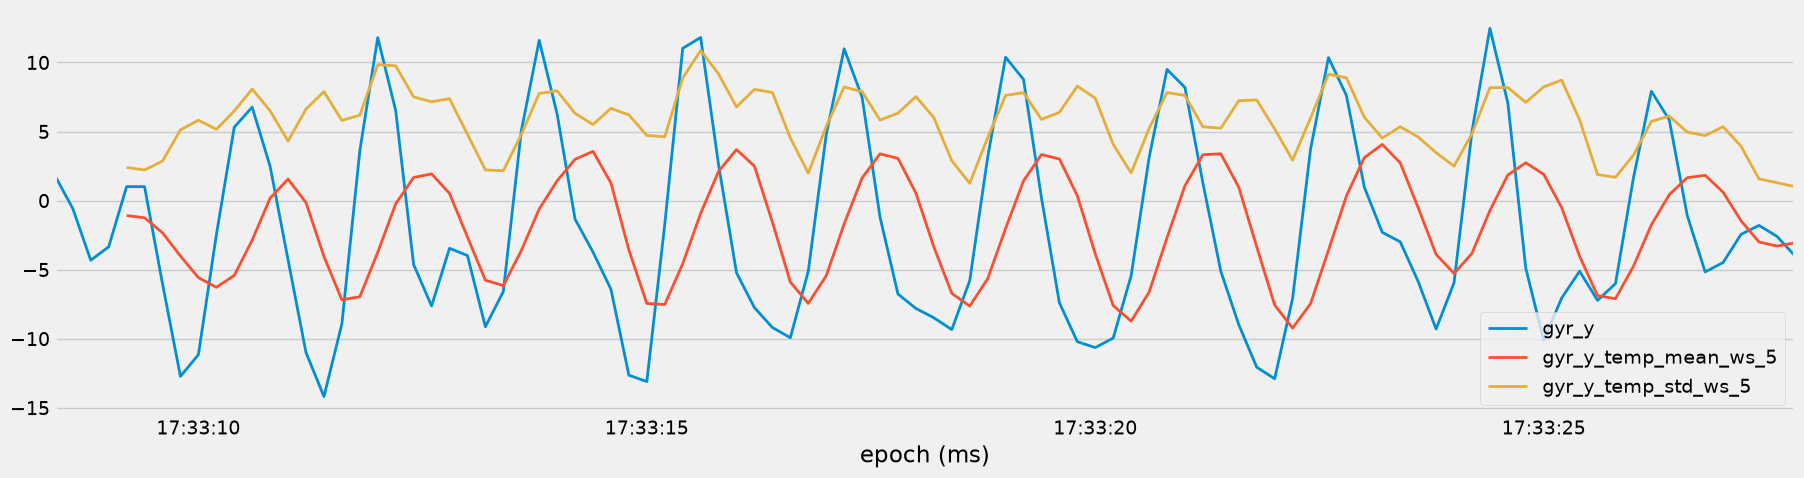

In [ ]:
subset[["gyr_y", "gyr_y_temp_mean_ws_5", "gyr_y_temp_std_ws_5"]].plot()

In [ ]:
from FrequencyAbstraction import FourierTransformation

Applying Fourier transformations to set 30
Applying Fourier transformations to set 1
Applying Fourier transformations to set 31
Applying Fourier transformations to set 3
Applying Fourier transformations to set 9
Applying Fourier transformations to set 32
Applying Fourier transformations to set 10
Applying Fourier transformations to set 33
Applying Fourier transformations to set 11
Applying Fourier transformations to set 34
Applying Fourier transformations to set 35
Applying Fourier transformations to set 15
Applying Fourier transformations to set 36
Applying Fourier transformations to set 16
Applying Fourier transformations to set 37
Applying Fourier transformations to set 17
Applying Fourier transformations to set 27
Applying Fourier transformations to set 38
Applying Fourier transformations to set 28
Applying Fourier transformations to set 29
Applying Fourier transformations to set 6
Applying Fourier transformations to set 65
Applying Fourier transformations to set 67
Applying Fourie

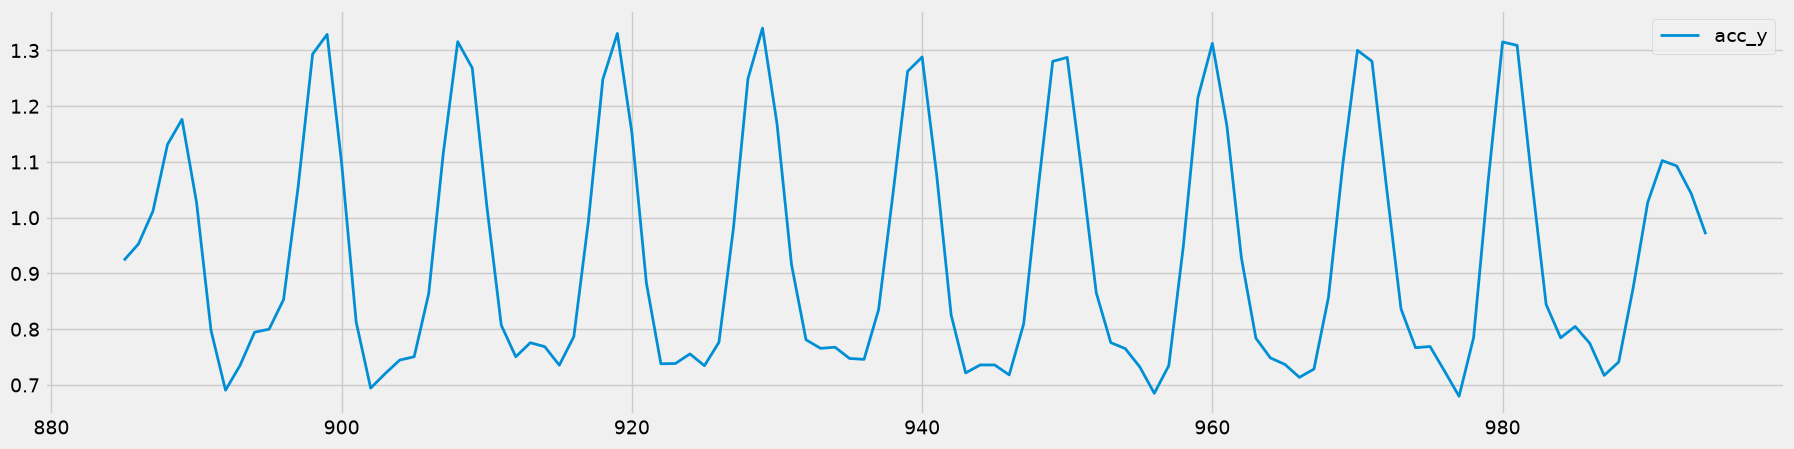

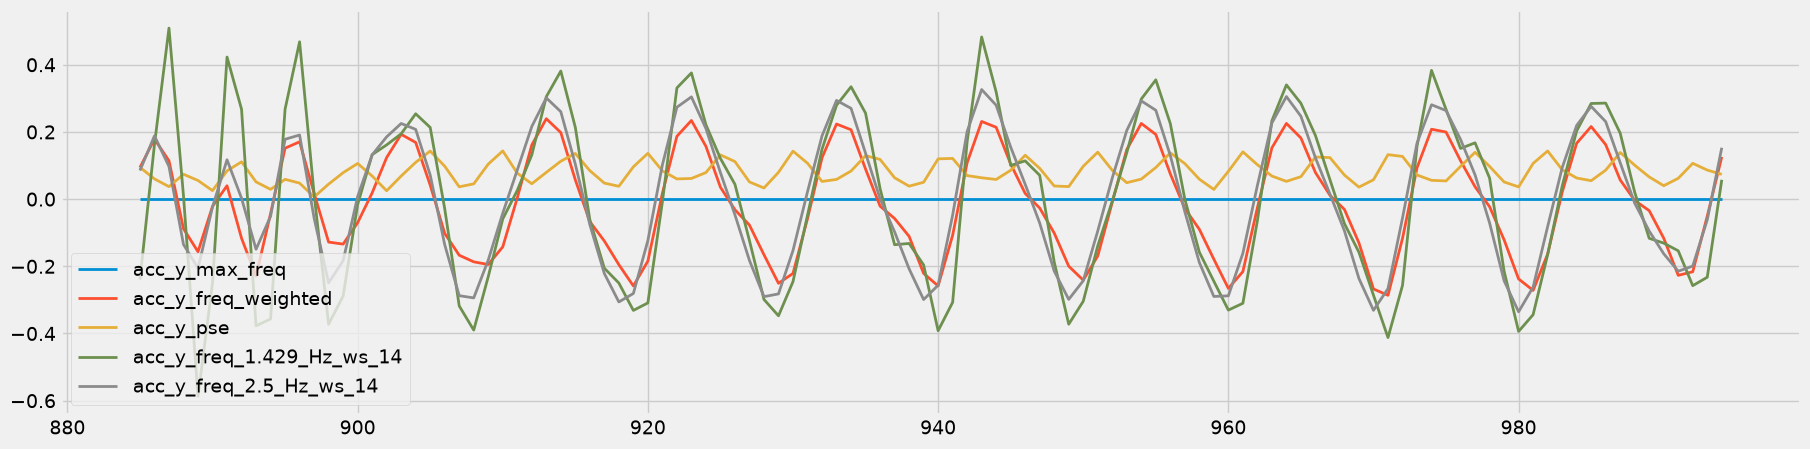

In [ ]:
df_freq = df_temporal.copy().reset_index()
FreqAbs = FourierTransformation()

fs = int(1000 / 200)
ws = int(2800 / 200)

df_freq = FreqAbs.abstract_frequency(df_freq, ["acc_y"], ws, fs)

# Visualize results
subset = df_freq[df_freq["set"] == 15]
subset[["acc_y"]].plot()
subset[
    [
        "acc_y_max_freq",
        "acc_y_freq_weighted",
        "acc_y_pse",
        "acc_y_freq_1.429_Hz_ws_14",
        "acc_y_freq_2.5_Hz_ws_14",
    ]
].plot()

df_freq_list = []
for s in df_freq["set"].unique():
    print(f"Applying Fourier transformations to set {s}")
    subset = df_freq[df_freq["set"] == s].reset_index(drop=True).copy()
    subset = FreqAbs.abstract_frequency(subset, predictor_columns, ws, fs)
    df_freq_list.append(subset)

df_freq = pd.concat(df_freq_list)

In [ ]:
df_freq = pd.concat(df_freq_list).set_index("epoch (ms)", drop=True)

In [ ]:
df_freq

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,label,category,participant,set,...,gyr_r_freq_weighted,gyr_r_pse,gyr_r_freq_0.0_Hz_ws_14,gyr_r_freq_0.357_Hz_ws_14,gyr_r_freq_0.714_Hz_ws_14,gyr_r_freq_1.071_Hz_ws_14,gyr_r_freq_1.429_Hz_ws_14,gyr_r_freq_1.786_Hz_ws_14,gyr_r_freq_2.143_Hz_ws_14,gyr_r_freq_2.5_Hz_ws_14
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013494,0.977001,-0.070995,-1.896395,2.439080,0.939616,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.400,0.006869,0.970257,-0.067545,2.129685,0.528678,-1.248135,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.600,-0.009603,0.963589,-0.073447,4.151973,-2.092258,-0.929804,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.800,-0.022998,0.965441,-0.083731,2.074477,-3.626288,0.880509,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:06.000,-0.020032,0.966784,-0.093783,1.041930,-1.219897,-2.260590,bench,heavy,B,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.045056,-0.974791,-0.061752,3.273522,-4.487268,0.133850,row,medium,E,90,...,-0.289293,0.211363,315.378553,-32.966667,25.312515,9.456436,-2.814943,-48.443419,-0.900828,-0.225067
2019-01-20 17:33:27.200,-0.042806,-1.020916,-0.057715,-2.514546,-2.449224,1.255524,row,medium,E,90,...,0.509833,0.608660,304.825579,-41.572736,57.022041,78.579281,-21.898935,55.881245,14.102476,9.598016
2019-01-20 17:33:27.400,-0.047074,-1.051656,-0.066326,-0.673530,-1.799975,1.193779,row,medium,E,90,...,0.625087,0.547018,266.538134,-67.414847,35.931545,37.829734,21.948169,22.258871,19.610711,29.452260


In [ ]:
df_freq = df_freq.dropna()
df_freq = df_freq.iloc[::2]

In [ ]:
df_cluster = df_freq.copy()

In [ ]:
cluster_columns = ["acc_x", "acc_y", "acc_z"]
k_values = range(2, 10)
inertias = []

In [ ]:
for k in k_values:
    subset = df_cluster[cluster_columns]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset)
    inertias.append(kmeans.inertia_)

NameError: name 'KMeans' is not defined

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
for k in k_values:
    subset = df_cluster[cluster_columns]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset)
    inertias.append(kmeans.inertia_)

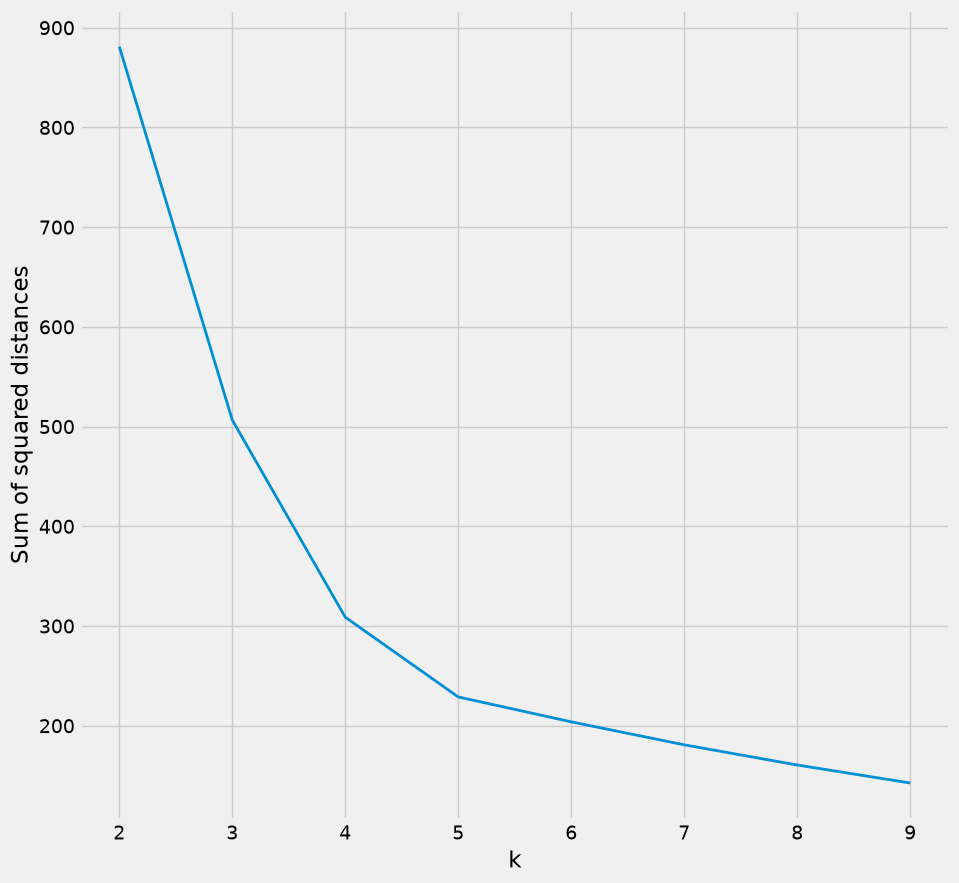

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(k_values, inertias)
plt.xlabel("k")
plt.ylabel("Sum of squared distances")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster[cluster_columns]
df_cluster["cluster"] = kmeans.fit_predict(subset)

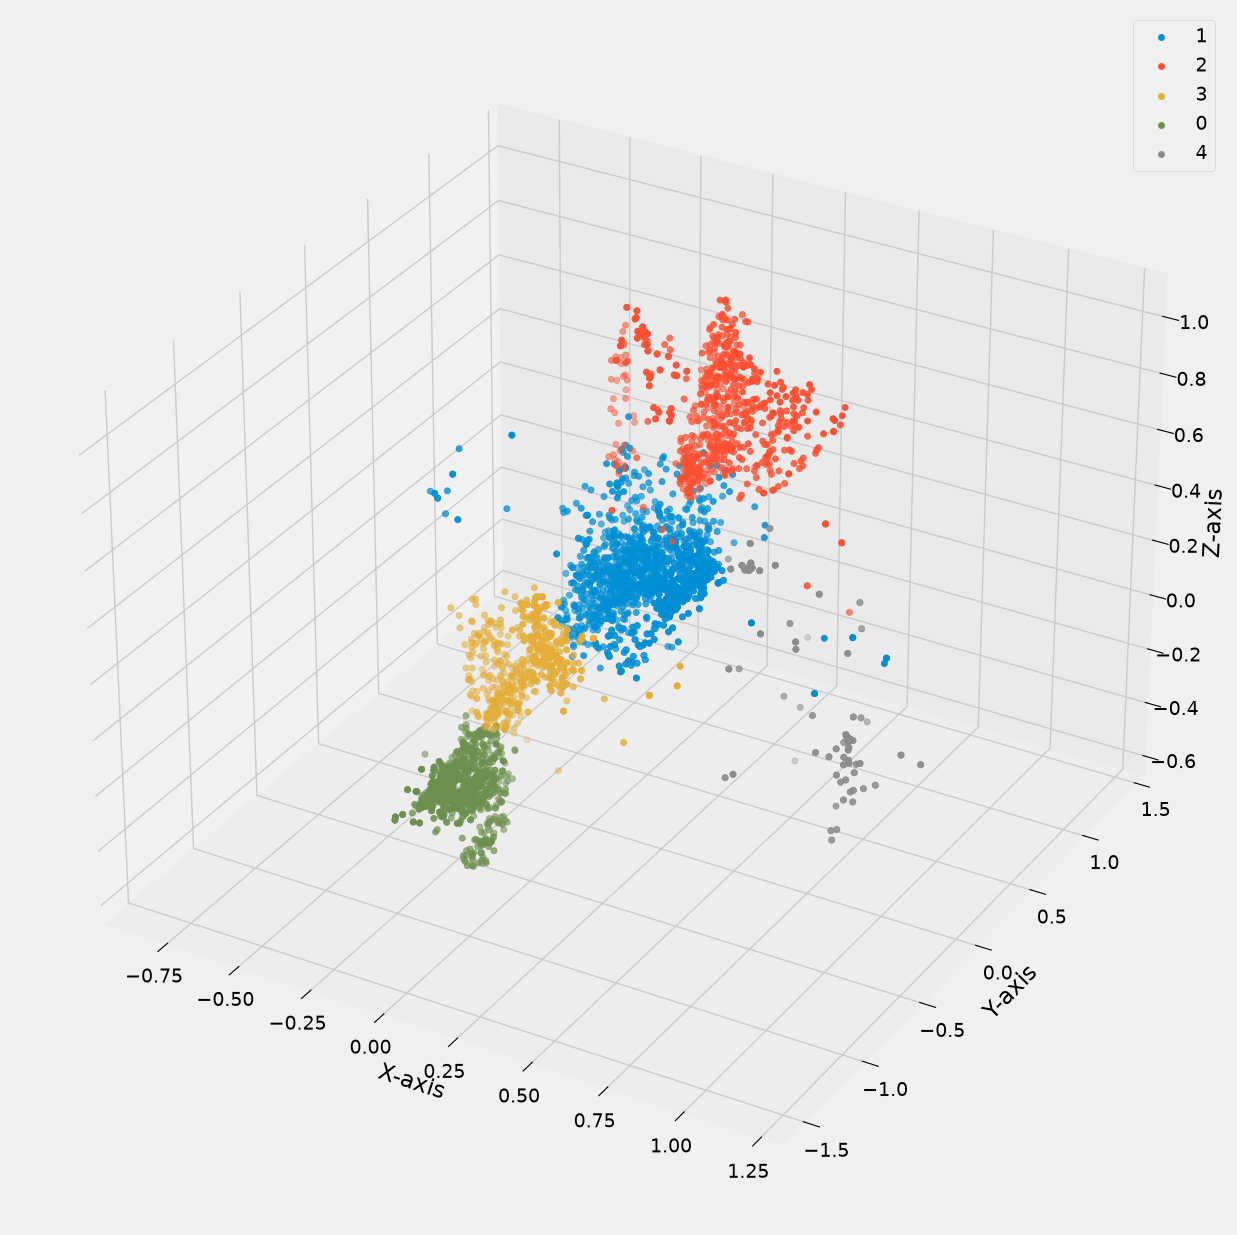

In [ ]:
# Plot clusters
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection="3d")
for c in df_cluster["cluster"].unique():
    subset = df_cluster[df_cluster["cluster"] == c]
    ax.scatter(subset["acc_x"], subset["acc_y"], subset["acc_z"], label=c)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.legend()
plt.show()

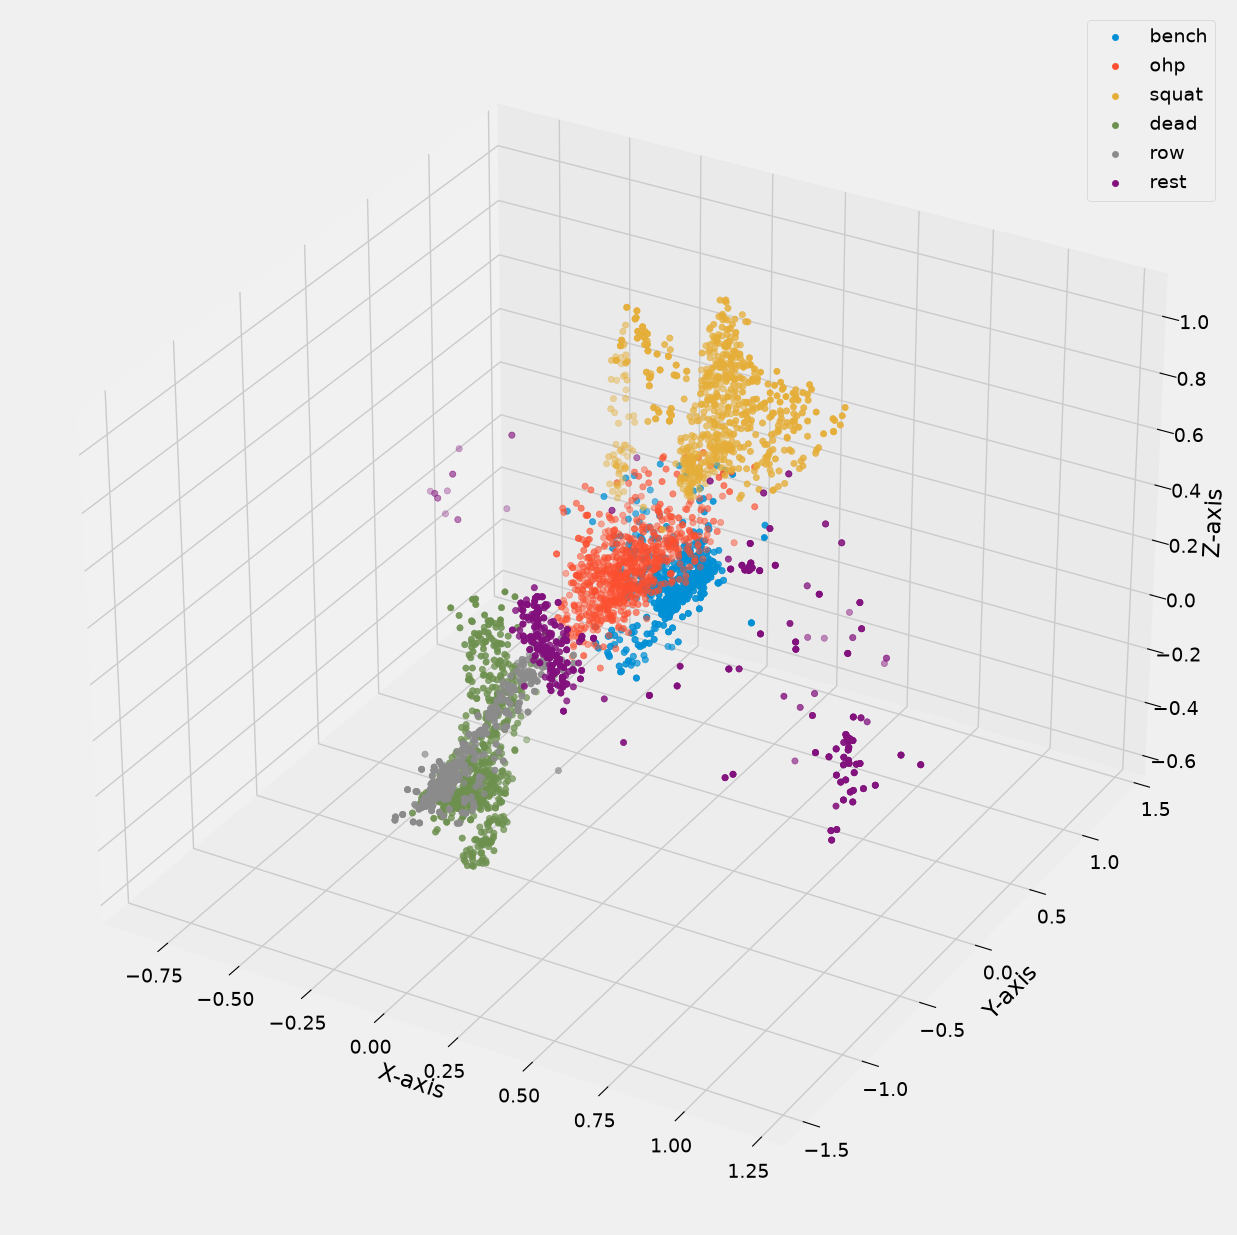

In [ ]:
# Plot accelerometer data to compare
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection="3d")
for l in df_cluster["label"].unique():
    subset = df_cluster[df_cluster["label"] == l]
    ax.scatter(subset["acc_x"], subset["acc_y"], subset["acc_z"], label=l)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.legend()
plt.show()

In [ ]:
df_cluster.to_pickle("../../data/interim/03_data_features.pkl")